<a href="https://colab.research.google.com/github/Nikky316/airline-satisfaction-prediction/blob/main/Customer_Satisfaction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Airline Customer Satisfaction Prediction

This project uses Logistic Regression to predict whether an airline customer is satisfied or dissatisfied.

In [31]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv("617ec7a0-b7f1-423e-b810-23f59803ffb6.csv")

df.head()


Saving 617ec7a0-b7f1-423e-b810-23f59803ffb6.csv to 617ec7a0-b7f1-423e-b810-23f59803ffb6 (2).csv


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## Dataset Overview
The dataset contains passenger information, service ratings, travel details, and flight delay information.

In [32]:
df['satisfaction'].value_counts()

,count
satisfaction,
satisfied,71087
dissatisfied,58793


In [33]:
df['satisfaction'] = df['satisfaction'].map({
    'satisfied': 1,
    'dissatisfied': 0
})

df['satisfaction'].value_counts()

,count
satisfaction,
1,71087
0,58793


## Data Preprocessing

The following steps were performed:

- Converted satisfaction into a binary target variable
- Filled missing values
- Encoded categorical variables

In [34]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.isnull().sum().sum()

np.int64(0)

In [35]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0.0,False,True,True,False
1,1,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305.0,False,True,False,False
2,1,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0.0,False,True,True,False
3,1,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0.0,False,True,True,False
4,1,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0.0,False,True,True,False


In [36]:
from sklearn.model_selection import train_test_split

X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Training

A Logistic Regression model was trained using the processed dataset.

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

## Model Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- Confusion Matrix

In [39]:
y_pred = model.predict(X_test_scaled)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8273021250384971
Precision: 0.8433018537950332
Recall: 0.8429480455912174

Confusion Matrix:

[[ 9435  2240]
 [ 2246 12055]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11675
           1       0.84      0.84      0.84     14301

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



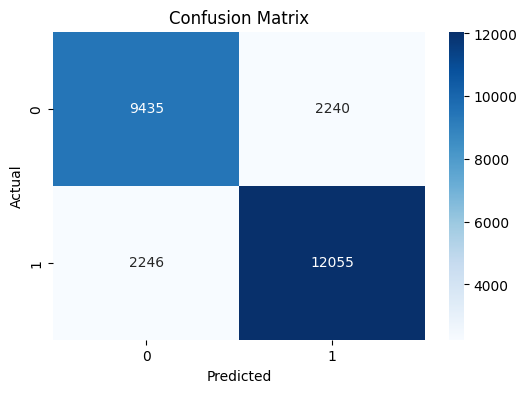

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Evaluation

The trained Logistic Regression model is evaluated using Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix.

In [42]:
y_pred = model.predict(X_test_scaled)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.8273021250384971
Precision: 0.8433018537950332
Recall: 0.8429480455912174


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81     11675
           1       0.84      0.84      0.84     14301

    accuracy                           0.83     25976
   macro avg       0.83      0.83      0.83     25976
weighted avg       0.83      0.83      0.83     25976



### Classification Report Interpretation

- Precision measures how accurate positive predictions are.
- Recall measures how well the model identifies satisfied customers.
- F1-score balances precision and recall.
- Higher values indicate better model performance.

In [45]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 9435  2240]
 [ 2246 12055]]


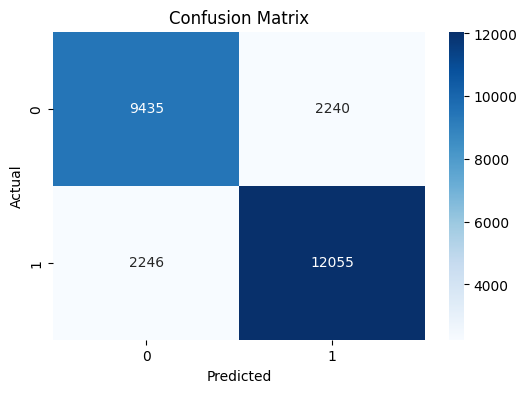

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows:

- True Positives (correctly predicted satisfied customers)
- True Negatives (correctly predicted dissatisfied customers)
- False Positives
- False Negatives

A strong model should have high values along the diagonal.

## Logistic Regression Coefficients

In [47]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
7,Inflight entertainment,0.976504
2,Seat comfort,0.402414
10,On-board service,0.399733
13,Checkin service,0.355782
9,Ease of Online booking,0.321014
11,Leg room service,0.304159
15,Online boarding,0.185137
5,Gate location,0.175652
8,Online support,0.136880
12,Baggage handling,0.108904


### Coefficient Interpretation

Positive coefficients increase the likelihood of customer satisfaction.

Negative coefficients decrease the likelihood of customer satisfaction.

Features with the largest positive coefficients have the strongest positive influence on satisfaction.

## Relationship Between Inflight Entertainment and Satisfaction

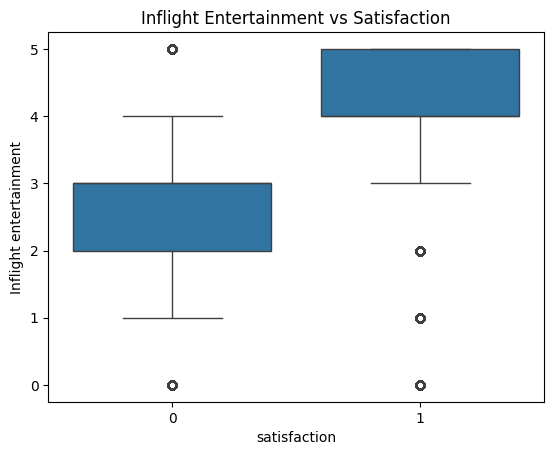

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='satisfaction',
    y='Inflight entertainment',
    data=df
)

plt.title("Inflight Entertainment vs Satisfaction")
plt.show()

### Observation

Satisfied passengers generally give higher ratings for inflight entertainment than dissatisfied passengers.

This suggests that entertainment quality is an important driver of customer satisfaction.

## Key Insights

- In-flight entertainment contributes positively to customer satisfaction.
- Flight delays negatively affect customer satisfaction.
- Better online services improve customer experience.
- Service quality plays an important role in overall satisfaction.

## Recommendations

- Improve in-flight Wi-Fi quality.
- Reduce departure and arrival delays.
- Continue improving onboard entertainment.
- Enhance passenger service experience.

## Conclusion

The Logistic Regression model successfully predicts airline customer satisfaction using service quality and travel-related features. The results provide useful insights that can help airlines improve customer experience and retention.